# Membrane Channel — Registration Error Over Time (WBI vs SPARK)

Comparison of WBI (getMotion, zRatio=10) and SPARK (Phase Persist, fixed).
Metrics computed on **foreground pixels only**, normalized to [0, 255].

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load WBI and SPARK metrics
WBI_CSV   = Path("/mnt/data21T_2/cyf/f260517/GM_mapped_v2_layer3/metrics.csv")
SPARK_CSV = Path("/mnt/data21T_2/cyf/f260517/PP_baseline_l3/metrics.csv")
OUT_DIR = Path("/home/cyf/wbi/Virginia/code_for_paper/Fig3")

df_wbi   = pd.read_csv(WBI_CSV)
df_spark = pd.read_csv(SPARK_CSV)
frames = df_wbi["frame"].values

# Smoothing helper
def smooth(series, window=5):
    return series.rolling(window, center=True, min_periods=1).mean()

print(f"WBI:   {len(df_wbi)} frames  |  SPARK: {len(df_spark)} frames")
print(f"WBI   mem_GradNCC mean: {df_wbi['mem_GradNCC'].mean():.4f}")
print(f"SPARK mem_GradNCC mean: {df_spark['mem_GradNCC'].mean():.4f}")

WBI:   200 frames  |  SPARK: 200 frames
WBI   mem_GradNCC mean: 0.7580
SPARK mem_GradNCC mean: 0.7876


Saved to membrane_RMSE_wbi_vs_SPARK.png


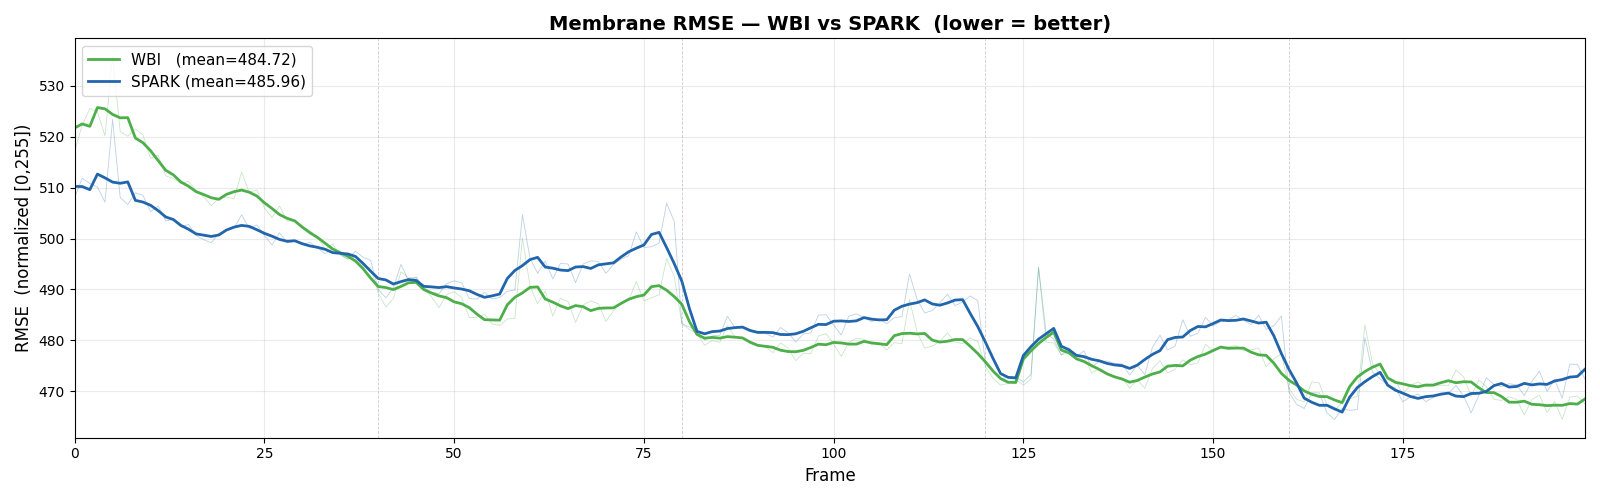

In [2]:
# ================================================================
# Figure 1: Membrane RMSE — WBI vs SPARK
# ================================================================
WINDOW = 5
c_wbi   = "#4DAF4A"   # green
c_spark = "#2166AC"   # blue

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(frames, df_wbi["mem_RMSE"], color=c_wbi, lw=0.6, alpha=0.3)
ax.plot(frames, df_spark["mem_RMSE"], color=c_spark, lw=0.6, alpha=0.3)
ax.plot(frames, smooth(df_wbi["mem_RMSE"], WINDOW), color=c_wbi, lw=2.0, label=f"WBI   (mean={df_wbi['mem_RMSE'].mean():.2f})")
ax.plot(frames, smooth(df_spark["mem_RMSE"], WINDOW), color=c_spark, lw=2.0, label=f"SPARK (mean={df_spark['mem_RMSE'].mean():.2f})")

for rf in [40, 80, 120, 160]:
    ax.axvline(x=rf, color="gray", lw=0.6, ls="--", alpha=0.4)

ax.set_ylabel("RMSE  (normalized [0,255])", fontsize=12)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Membrane RMSE — WBI vs SPARK  (lower = better)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 199)

fig.tight_layout()
fig.savefig(str(OUT_DIR / "membrane_RMSE_wbi_vs_SPARK.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to membrane_RMSE_wbi_vs_SPARK.png")

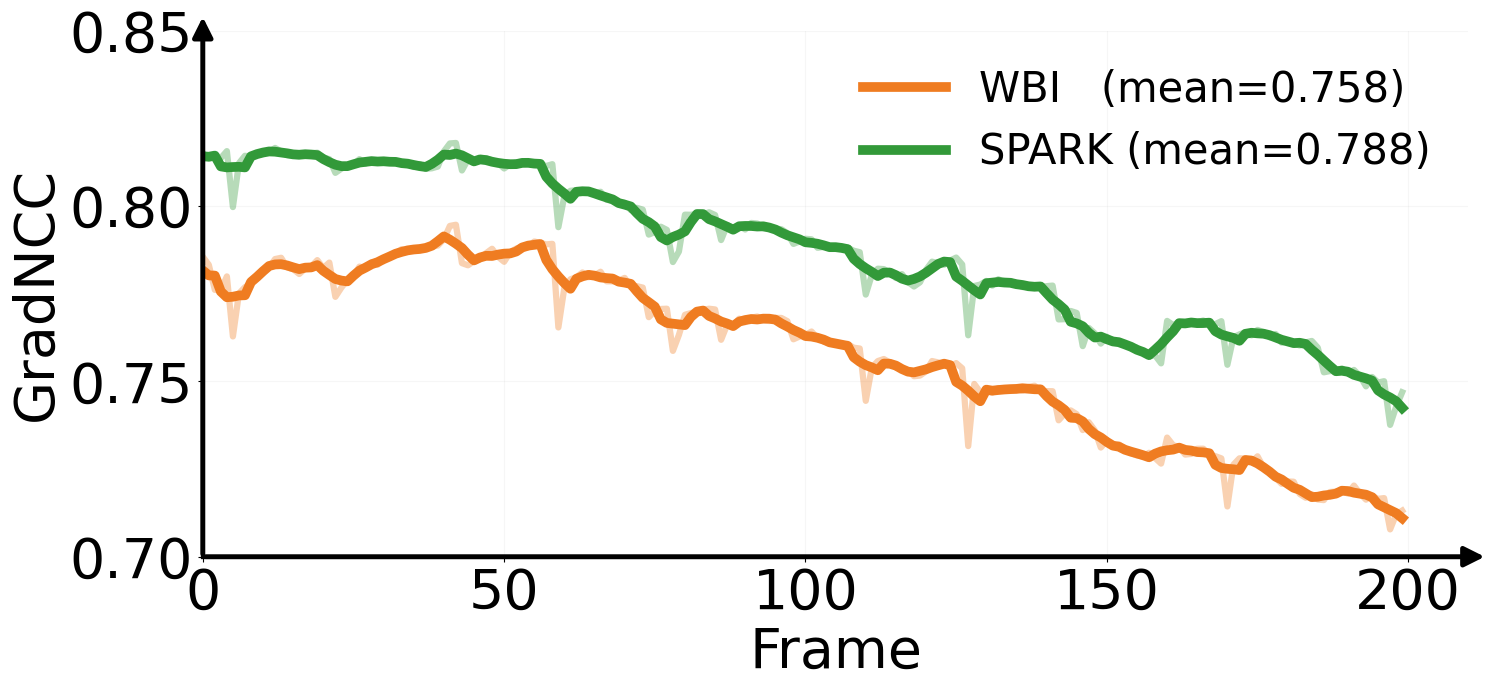

Saved to membrane_GradNCC_wbi_vs_SPARK.pdf


In [21]:
# ================================================================
# Figure 2: Membrane GradNCC — WBI vs SPARK
# ================================================================
WINDOW = 5
c_wbi   = "#ef7c21"   # orange
c_spark = "#329939"   # green

fig, ax = plt.subplots(figsize=(15, 7))

# 平滑（平均）曲线为主：粗线不透明，突出整体趋势
ax.plot(frames, smooth(df_wbi["mem_GradNCC"], WINDOW), color=c_wbi, lw=7.0,
        label=f"WBI   (mean={df_wbi['mem_GradNCC'].mean():.3f})")
ax.plot(frames, smooth(df_spark["mem_GradNCC"], WINDOW), color=c_spark, lw=7.0,
        label=f"SPARK (mean={df_spark['mem_GradNCC'].mean():.3f})")
# 真实曲线为辅：较粗 + 中低透明度叠加在上层，展示原始噪声细节
ax.plot(frames, df_wbi["mem_GradNCC"], color=c_wbi, lw=4.5, alpha=0.35)
ax.plot(frames, df_spark["mem_GradNCC"], color=c_spark, lw=4.5, alpha=0.35)

ax.set_ylabel("GradNCC", fontsize=40)
ax.set_xlabel("Frame", fontsize=40)
ax.tick_params(axis="both", labelsize=40)
ax.grid(True, alpha=0.1)
ax.set_xlim(0, 210)          # 横轴箭头末端 (210) 超出数据末端 (199)
ax.set_ylim(0.70, 0.85)      # 纵轴顶部高于曲线最高点 (0.818)

# 只保留 X/Y 坐标轴，去掉上、右框线
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(3.0)
ax.spines["left"].set_linewidth(3.0)

# 坐标轴末端加箭头（mutation_scale 控制箭头大小，越大越明显）
ax.annotate("", xy=(1.015, 0), xycoords="axes fraction", xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=3.5, mutation_scale=30))
ax.annotate("", xy=(0, 1.032), xycoords="axes fraction", xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=3.5, mutation_scale=30))

ax.legend(fontsize=30, loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig(str(OUT_DIR / "membrane_GradNCC_wbi_vs_SPARK.pdf"), bbox_inches="tight")
plt.show()
print("Saved to membrane_GradNCC_wbi_vs_SPARK.pdf")